### Step 3：加入硬约束的轨迹优化$(|x|\le L, |u|\le u_{max})$

在 Step 2 的基础上加入推车位置和输入约束，得到**可行的约束轨迹**。

思路：
- 先用无约束求解得到一条参考轨迹
- 统计该轨迹的最大位移与最大输入
- 设定约束小于极值，并重新求解
- 比较新的轨迹与输入变化

我们可以调整$dt_{min}$和$dt_{max}$的值,以及约束的比例。我们这里选0.05，0.20和0.7，已经到了比较极限的位置，很难再约束，从下面的u-t图也可以看到我们的u已经尽力。如果还想调小约束比例的话可能需要增大$dt_{max}$才可以。

In [ ]:
# 配置环境
import numpy as np
import matplotlib.pyplot as plt
from pydrake.all import (
    DirectCollocation,
    DiagramBuilder,
    MeshcatVisualizer,
    MultibodyPlant,
    MultibodyPositionToGeometryPose,
    Parser,
    PiecewisePolynomial,
    SceneGraph,
    Simulator,
    SnoptSolver,
    Solve,
    StartMeshcat,
    TrajectorySource,
    )
from underactuated import ConfigureParser

def solve_cartpole_dircol(
    num_time_samples=21,
    dt_min=0.05,
    dt_max=0.2,
    u_weight=1.0,
    time_weight=1.0,
    x_limit=None,
    u_limit=None,
    ):
    #  构建植物模型
    plant = MultibodyPlant(time_step=0.0)
    parser = Parser(plant)
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()
    context = plant.CreateDefaultContext()

    # 直接转录设置
    dircol = DirectCollocation(
        plant,
        context,
        num_time_samples=num_time_samples,
        minimum_time_step=dt_min,
        maximum_time_step=dt_max,
        input_port_index=plant.get_actuation_input_port().get_index(),
    )
    prog = dircol.prog()

    # 初末态约束（从下垂到直立）
    x0 = np.array([0.0, 0.0, 0.0, 0.0])
    xf = np.array([0.0, np.pi, 0.0, 0.0])
    prog.AddBoundingBoxConstraint(x0, x0, dircol.initial_state())
    prog.AddBoundingBoxConstraint(xf, xf, dircol.final_state())

    #  硬约束
    if x_limit is not None:
        for i in range(num_time_samples):
            prog.AddBoundingBoxConstraint(-x_limit, x_limit, dircol.state(i)[0])
    if u_limit is not None:
        for i in range(num_time_samples):
            prog.AddBoundingBoxConstraint(-u_limit, u_limit, dircol.input(i)[0])

    # 代价函数（输入能量 + 时间）
    u = dircol.input()
    dircol.AddRunningCost(u_weight * u[0] ** 2)
    dircol.AddFinalCost(time_weight * dircol.time())

    # 初始猜测
    state_guess = PiecewisePolynomial.FirstOrderHold(
        [0.0, 1.0], np.vstack((x0, xf)).T
    )
    input_guess = PiecewisePolynomial.FirstOrderHold(
        [0.0, 1.0], np.zeros((1, 2))
    )
    dircol.SetInitialTrajectory(input_guess, state_guess)

    # 求解
    solver = SnoptSolver()
    if solver.available():
        result = solver.Solve(prog)
    else:
        result = Solve(prog)

    if not result.is_success():
        print("求解失败：请调整约束或离散参数")
        return None, None

    xtraj = dircol.ReconstructStateTrajectory(result)
    utraj = dircol.ReconstructInputTrajectory(result)
    return xtraj, utraj

先解一次无约束问题，用它的极值来设置约束（可以手动调比例），约束越大差别越明显。

In [ ]:
# 无约束轨迹
xtraj0, utraj0 = solve_cartpole_dircol()
if xtraj0 is None:
    raise RuntimeError("无约束求解失败，无法继续")

#  计算极值并设置约束
ts0 = np.linspace(xtraj0.start_time(), xtraj0.end_time(), 201)
x_samples0 = xtraj0.vector_values(ts0)
u_samples0 = utraj0.vector_values(ts0)
x_max = float(np.max(np.abs(x_samples0[0, :])))
u_max = float(np.max(np.abs(u_samples0[0, :])))

scale = 0.7  # 约束比例（越小越严格）
L = scale * x_max
u_limit = scale * u_max
print(f"无约束极值: |x|max={x_max:.3f}, |u|max={u_max:.3f}")
print(f"设置约束: |x|<=L={L:.3f}, |u|<=u_max={u_limit:.3f}")

无约束极值: |x|max=1.114, |u|max=108.492
设置约束: |x|<=L=0.780, |u|<=u_max=75.944


在约束下重新求解，并画出新的状态/输入轨迹。

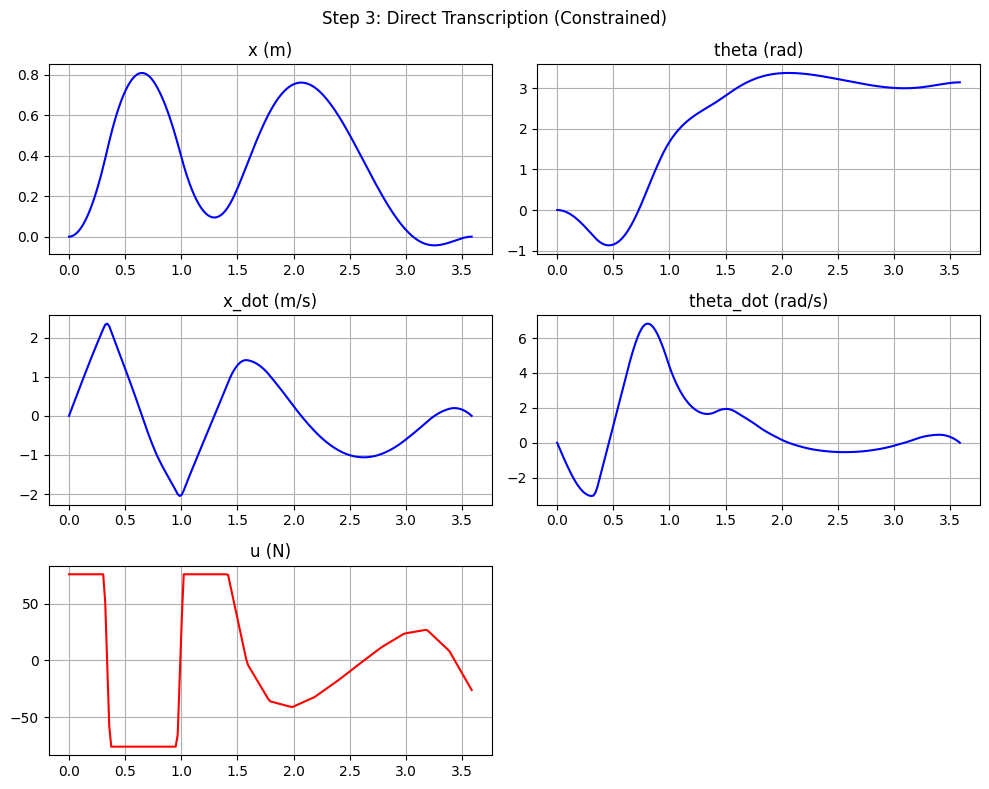

Step 3 约束轨迹求解成功


In [ ]:
# 约束下的求解
xtraj, utraj = solve_cartpole_dircol(x_limit=L, u_limit=u_limit)
if xtraj is None:
    raise RuntimeError("约束求解失败，请放宽约束或增大时间步/节点数")

# 可视化
ts = np.linspace(xtraj.start_time(), xtraj.end_time(), 201)
x_samples = xtraj.vector_values(ts)
u_samples = utraj.vector_values(ts)

fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()
labels = ["x (m)", "theta (rad)", "x_dot (m/s)", "theta_dot (rad/s)"]
for i in range(4):
    axes[i].plot(ts, x_samples[i, :], "b-")
    axes[i].set_title(labels[i])
    axes[i].grid(True)
axes[4].plot(ts, u_samples[0, :], "r-")
axes[4].set_title("u (N)")
axes[4].grid(True)
axes[5].axis("off")
plt.suptitle("Step 3: Direct Transcription (Constrained)")
plt.tight_layout()
plt.show()

print("Step 3 约束轨迹求解成功")

下面画**约束轨迹**的相位图，用来观察状态在相空间的变化。

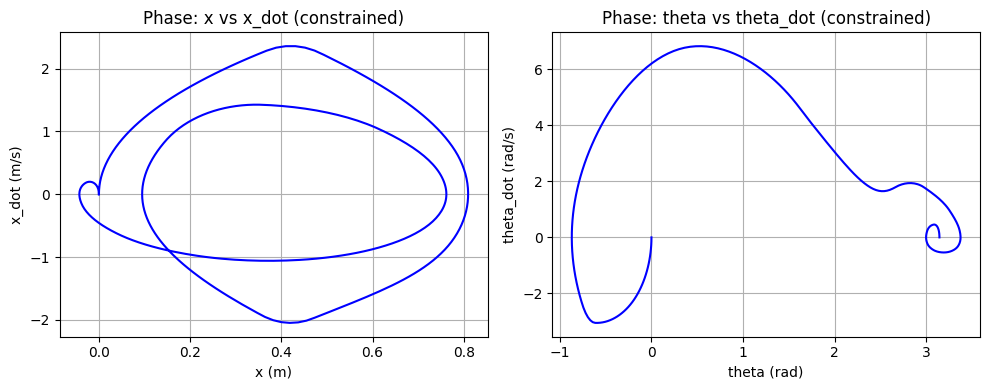

In [ ]:
# 约束轨迹相位图
def plot_phase_portraits(xtraj, num_samples=400):
    if xtraj is None:
        print("没有相位图可画，请先成功求解")
        return
    ts = np.linspace(xtraj.start_time(), xtraj.end_time(), num_samples)
    x_samples = xtraj.vector_values(ts)
    x = x_samples[0, :]
    theta = x_samples[1, :]
    xdot = x_samples[2, :]
    thetadot = x_samples[3, :]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(x, xdot, "b-")
    axes[0].set_xlabel("x (m)")
    axes[0].set_ylabel("x_dot (m/s)")
    axes[0].set_title("Phase: x vs x_dot (constrained)")
    axes[0].grid(True)

    axes[1].plot(theta, thetadot, "b-")
    axes[1].set_xlabel("theta (rad)")
    axes[1].set_ylabel("theta_dot (rad/s)")
    axes[1].set_title("Phase: theta vs theta_dot (constrained)")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# 运行相位图
plot_phase_portraits(xtraj)

下面用 Meshcat 回放带约束的轨迹。

In [ ]:
# 约束轨迹可视化（Meshcat 回放）
def visualize_cartpole_trajectory(xtraj):
    if xtraj is None:
        print("没有可视化的轨迹，请先成功求解")
        return

    meshcat = StartMeshcat()
    builder = DiagramBuilder()
    plant = MultibodyPlant(time_step=0.0)
    scene_graph = builder.AddSystem(SceneGraph())
    plant.RegisterAsSourceForSceneGraph(scene_graph)
    parser = Parser(plant, scene_graph)
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()

    source = builder.AddSystem(TrajectorySource(xtraj))
    pos_to_pose = builder.AddSystem(
        MultibodyPositionToGeometryPose(plant, input_multibody_state=True)
    )
    builder.Connect(source.get_output_port(0), pos_to_pose.get_input_port())
    builder.Connect(
        pos_to_pose.get_output_port(),
        scene_graph.get_source_pose_port(plant.get_source_id()),
    )
    meshcat.Set2dRenderMode(xmin=-2.5, xmax=2.5, ymin=-1.0, ymax=2.5)
    visualizer = MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
    diagram = builder.Build()
    simulator = Simulator(diagram)

    visualizer.StartRecording(False)
    simulator.AdvanceTo(xtraj.end_time())
    visualizer.PublishRecording()

# 回放
visualize_cartpole_trajectory(xtraj)

INFO:drake:Meshcat listening for connections at http://localhost:7002
